In [ ]:
from sklearn.datasets import load_iris
import pandas as pd

print(load_iris()["DESCR"])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [50]:
X, y = load_iris(return_X_y=True, as_frame=True) # without target_names, only codes
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [33]:
y.value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [34]:
# remove class 0 (first 50 rows), leaving only 1 and 2 for binary classification
X = X[50:]
y = y[50:] - 1 # -1 shifts values 1 and 2 to 0 and 1
two_species = pd.concat([X, y], axis=1)
two_species.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
132,6.4,2.8,5.6,2.2,1
54,6.5,2.8,4.6,1.5,0
84,5.4,3.0,4.5,1.5,0
53,5.5,2.3,4.0,1.3,0
133,6.3,2.8,5.1,1.5,1


In [35]:
# see which features are most relevant to target
two_species.corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
sepal length (cm),1.000000,0.553855,0.828479,0.593709,0.494305
sepal width (cm),0.553855,1.000000,0.519802,0.566203,0.308080
petal length (cm),0.828479,0.519802,1.000000,0.823348,0.786424
petal width (cm),0.593709,0.566203,0.823348,1.000000,0.828129
target,0.494305,0.308080,0.786424,0.828129,1.000000


<Axes: xlabel='petal width (cm)', ylabel='sepal width (cm)'>

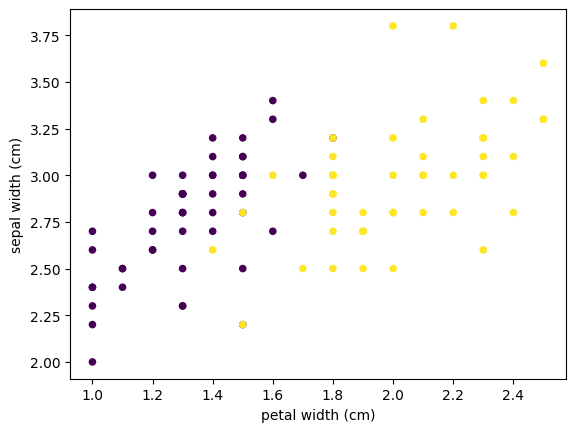

In [45]:
# per above: petal length and petal width have the highest correlation with the target
two_species.plot.scatter(x="petal width (cm)", y="sepal width (cm)", c="target", colormap="viridis", colorbar=False) # colorbar makes no sense as there are only two values

In [ ]:
# Alternative ways to load and transform iris dataset:

from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris(as_frame=True) # print(iris.DESCR)
iris_df = iris.frame # frame = iris.data + iris.target ([150 rows x 5 columns])

# Alternative way to make df:
# iris = load_iris()
# iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
# iris_df['target'] = iris.target
# iris_df['species'] = iris_df['target'].map({0: iris.target_names[0], 1: iris.target_names[1], 2: iris.target_names[2]})


# Adding column 'species':
# 1. numpy indexing:
iris_df["species"] = iris.target_names[iris_df["target"]] # or [iris.target] as indexing

# 2. map dict made of enumerated "target_names" array to "target" column values (codes):
iris_df["species1"] = iris_df["target"].map(dict(enumerate(iris.target_names)))

# 3. using pd.Categorical (best for ML, but somehow classifies 1 virginica wrong?):
iris_df["species2"] = pd.Categorical.from_codes(
    iris["target"], # or [iris.target]
    categories=iris.target_names
    )
iris_df = iris_df.drop(["species1", "species2"], axis=1)

# Filtering 2 species for illustrating classification:
# 1. leave Setosa and Versicolor:
df_subset = iris_df[iris_df['species'].isin(['setosa', 'versicolor'])]
# 2. remove Virginica:
df_subset1 = iris_df.drop(iris_df[iris_df['species'] == 'virginica'].index, axis=0)